<a href="https://colab.research.google.com/github/laceywang11/MSSP6070/blob/main/Week_7_Participation_Exercise_Lacey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata
import os

github_token = userdata.get('Git_HUB')
owner = 'laceywang11' # Replace with the GitHub repository owner
repository = 'MSSP6070' # Replace with the GitHub repository name

clone_url = f'https://{github_token}@github.com/{owner}/{repository}.git'

# Clone the repository
!git clone {clone_url}

Cloning into 'MSSP6070'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 135 (delta 54), reused 45 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 6.95 MiB | 5.27 MiB/s, done.
Resolving deltas: 100% (54/54), done.


In [8]:
df = pd.read_csv('/content/MSSP6070/InternetSales.csv', encoding='latin-1')
df.head()

/tmp/ipython-input-3402891406.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/MSSP6070/InternetSales.csv', encoding='latin-1')


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


In [9]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')
df['Year'] = df['OrderDate'].dt.year

In [11]:
Yearly_Sales= (
    df.groupby('Year', dropna=True)['SalesAmount']
      .sum()
      .reset_index()
      .sort_values('Year')
)
Yearly_Sales.head()

,Year,SalesAmount
0,2010,4.342104e+04
1,2011,7.075526e+06
2,2012,5.842485e+06
3,2013,1.635155e+07
4,2014,4.569472e+04


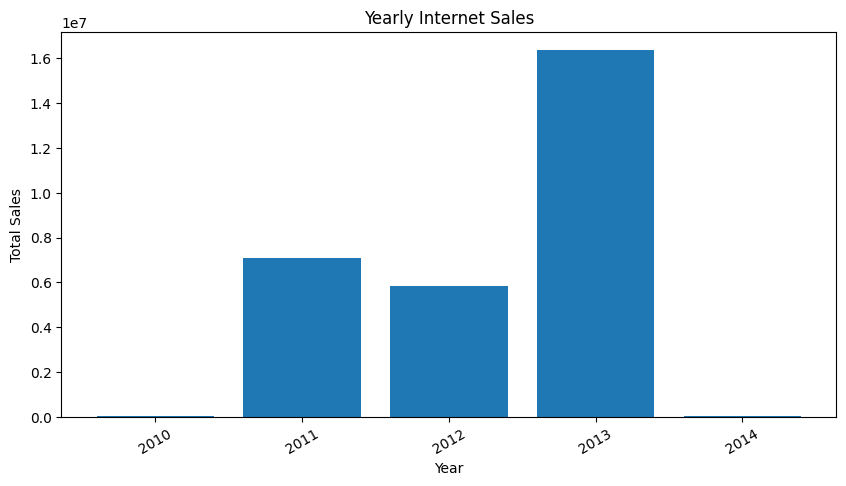

In [18]:
plt.figure(figsize=(10, 5))
plt.bar(Yearly_Sales['Year'].astype(str), Yearly_Sales["SalesAmount"])
plt.title('Yearly Internet Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)
plt.show()

In [24]:
plt.savefig('/content/MSSP6070/WeeklyModules/Week7/Yearly_Sales.pdf',
            format='pdf', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>